### Approach 3: Region-based Mean RGB + Spatial Coordinates

In this approach, the image is divided into fixed-size regions, and each region
is treated as a single sample. The feature vector is computed by averaging the
RGB values of all pixels in the region and combining them with the region’s
mean spatial location.

Region-level aggregation reduces pixel-level noise and improves robustness,
while preserving essential appearance and spatial information.

**Feature Vector:** (mean R, mean G, mean B, mean x, mean y)  
**Sample Unit:** Region  
**Strengths:** Reduced noise, better generalization, efficient training  
**Limitations:** Coarse boundaries, loss of fine details  
**Expected Behavior:** Stable and accurate segmentation with block-like regions

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from pycocotools.coco import COCO
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# IMAGE_DIR = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train"
# COCO_JSON = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train/_annotations.coco.json"
IMAGE_DIR = "/content/drive/MyDrive/230077_vivekananda"
COCO_JSON = "/content/drive/MyDrive/230077_vivekananda/vivekananda.json"

coco = COCO(COCO_JSON)

print(f"Total images: {len(coco.imgs)}")
print(f"Total annotations: {len(coco.getAnnIds())}")

# Floor category IDs (adjust if needed)
FLOOR_CAT_IDS = [0, 1]

loading annotations into memory...
Done (t=0.80s)
creating index...
index created!
Total images: 10
Total annotations: 10


In [3]:
img_ids = list(coco.imgs.keys())
print(f"Images to process: {len(img_ids)}")

Images to process: 10


In [4]:
REGION_SIZE = 32  # region = 32x32 pixels

X = []
y = []

print("Extracting region-level features...")

for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info["file_name"])
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w = img.shape[:2]

    # Build floor mask
    floor_mask = np.zeros((h, w), dtype=np.uint8)
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        if ann["category_id"] in FLOOR_CAT_IDS:
            floor_mask |= coco.annToMask(ann)

    # Slide over regions
    for y0 in range(0, h - REGION_SIZE, REGION_SIZE):
        for x0 in range(0, w - REGION_SIZE, REGION_SIZE):
            region = img[y0:y0+REGION_SIZE, x0:x0+REGION_SIZE]
            region_mask = floor_mask[y0:y0+REGION_SIZE, x0:x0+REGION_SIZE]

            # Label region by majority vote
            label = 1 if np.mean(region_mask) > 0.5 else 0

            # Mean RGB
            mean_rgb = region.reshape(-1, 3).mean(axis=0)

            # Mean normalized coordinates
            cx = (x0 + REGION_SIZE / 2) / w
            cy = (y0 + REGION_SIZE / 2) / h

            X.append([mean_rgb[0], mean_rgb[1], mean_rgb[2], cx, cy])
            y.append(label)

    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(img_ids)} images")

X = np.array(X)
y = np.array(y)

print(f"Total regions: {len(X)}")
print(f"Floor regions: {np.sum(y == 1)}")
print(f"Non-floor regions: {np.sum(y == 0)}")

Extracting region-level features...
Total regions: 7751
Floor regions: 3932
Non-floor regions: 3819


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train regions:", len(X_train))
print("Test regions:", len(X_test))

Train regions: 6200
Test regions: 1551


In [7]:
svm = SVC(
    kernel="linear",
    C=1,
    random_state=42
)

svm.fit(X_train, y_train)

SVC(C=1, kernel='linear', random_state=42)

In [8]:
y_pred = svm.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Train Accuracy:", svm.score(X_train, y_train))
print("Test Accuracy:", svm.score(X_test, y_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       764
           1       0.92      0.90      0.91       787

    accuracy                           0.91      1551
   macro avg       0.91      0.91      0.91      1551
weighted avg       0.91      0.91      0.91      1551

Train Accuracy: 0.9191935483870968
Test Accuracy: 0.9136041263700838


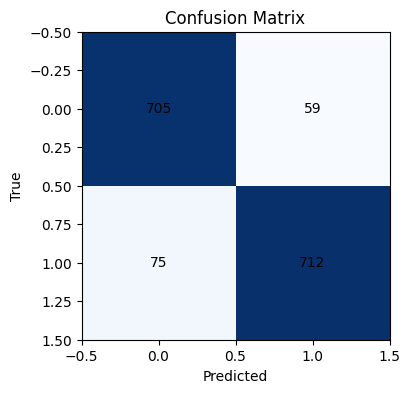

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [10]:
def predict_floor_regionwise(img_path, svm, scaler, region_size=32):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    for y0 in range(0, h - region_size, region_size):
        for x0 in range(0, w - region_size, region_size):
            region = img[y0:y0+region_size, x0:x0+region_size]
            mean_rgb = region.reshape(-1, 3).mean(axis=0)

            cx = (x0 + region_size / 2) / w
            cy = (y0 + region_size / 2) / h

            feat = np.array([[mean_rgb[0], mean_rgb[1], mean_rgb[2], cx, cy]])
            feat = scaler.transform(feat)

            pred = svm.predict(feat)[0]
            mask[y0:y0+region_size, x0:x0+region_size] = pred

    return img, mask

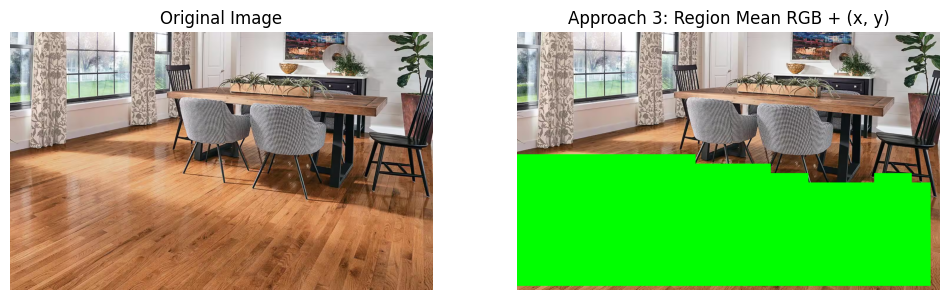

In [11]:
test_img_path = "/content/floor-1.avif"

img, mask = predict_floor_regionwise(test_img_path, svm, scaler)

overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Approach 3: Region Mean RGB + (x, y)")
plt.axis("off")

plt.show()

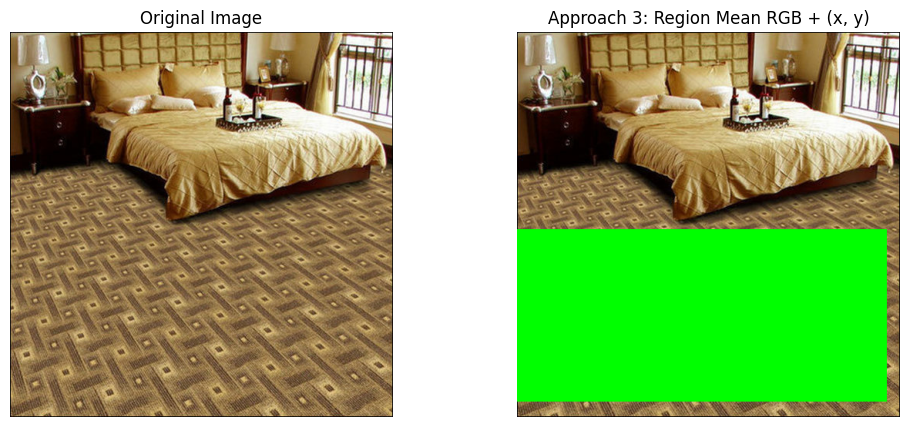

In [12]:
test_img_path = "/content/floor-10.jpg"

img, mask = predict_floor_regionwise(test_img_path, svm, scaler)

overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Approach 3: Region Mean RGB + (x, y)")
plt.axis("off")

plt.show()